In [1]:
%pip install seaborn xgboost

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
attacking = pd.read_csv("attacking.csv")
attempts = pd.read_csv("attempts.csv")
goals = pd.read_csv("goals.csv")

print(" Data Loaded Successfully")

 Data Loaded Successfully


In [4]:
print("\n--- ATTACKING DATASET ---")
print(attacking.head())
print("\nShape:", attacking.shape)
print("\nColumns:", attacking.columns)
print("\nSummary:\n", attacking.describe())


--- ATTACKING DATASET ---
   serial       player_name         club    position  assists  corner_taken  \
0       1   Bruno Fernandes  Man. United  Midfielder        7            10   
1       2   Vinicius Junior  Real Madrid     Forward        6             3   
2       2              Sané       Bayern  Midfielder        6             3   
3       4            Antony         Ajax     Forward        5             3   
4       5  Alexander-Arnold    Liverpool    Defender        4            36   

   offsides  dribbles  match_played  
0         2         7             7  
1         4        83            13  
2         3        32            10  
3         4        28             7  
4         0         9             9  

Shape: (176, 9)

Columns: Index(['serial', 'player_name', 'club', 'position', 'assists', 'corner_taken',
       'offsides', 'dribbles', 'match_played'],
      dtype='object')

Summary:
            serial     assists  corner_taken    offsides    dribbles  \
count  176.0

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 495.5 kB/s eta 0:03:26
   ---------------------------------------- 0.6/101.7 MB 6.1 MB/s eta 0:00:17
   ---------------------------------------- 0.8/101.7 MB 4.9 MB/s eta 0:00:21
   ---------------------------------------- 0.9/101.7 MB 4.6 MB/s eta 0:00:22
   ---------------------------------------- 0.9/101.7 MB 4.6 MB/s eta 0:00:22
   ---------------------------------------- 1.0/101.7 MB 3.2 MB/s eta 0:00:32
    --------------------------------------- 1.5/101.7 MB 4.4 MB/s eta 0:00:23
    --------------------------------------- 1.7/101.7 MB 4.3 MB/s eta 0:00:24
    -----------------------

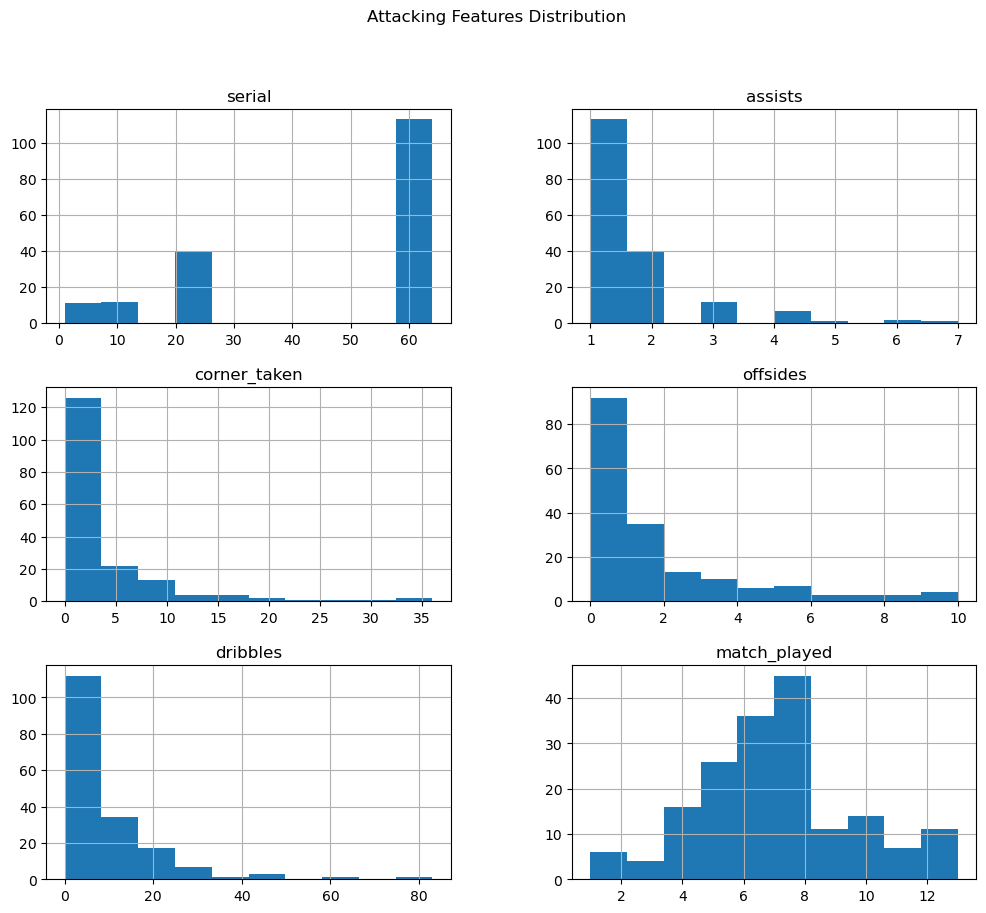

In [5]:
attacking.hist(figsize=(12,10))
plt.suptitle("Attacking Features Distribution")
plt.show()

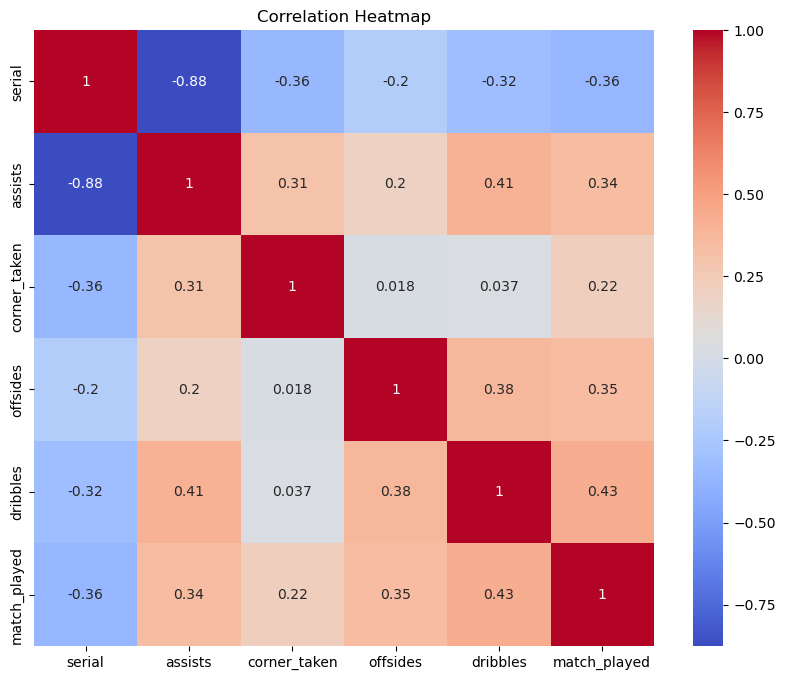

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(attacking.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [6]:
print("\nMissing Values:\n", attacking.isnull().sum())


Missing Values:
 serial          0
player_name     0
club            0
position        0
assists         0
corner_taken    0
offsides        0
dribbles        0
match_played    0
dtype: int64


In [7]:
def clean(df):
    df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
    return df

attacking = clean(attacking)
attempts = clean(attempts)
goals = clean(goals)

print("\n Column names cleaned")


 Column names cleaned


In [8]:
for d in [attacking, attempts, goals]:
    d['player_name'] = d['player_name'].str.lower().str.strip()

print("\n Player names standardized")


 Player names standardized


In [9]:
df = attempts.merge(goals, on="player_name", how="left", suffixes=("_att","_goal"))
df = df.merge(attacking, on="player_name", how="left")

print("\nBefore cleaning columns:", df.shape)


Before cleaning columns: (546, 29)


In [10]:
df.drop(columns=[
    'serial_att', 'serial_goal', 'serial',
    'club_att', 'club_goal', 'club',
    'position_att', 'position_goal'
], inplace=True, errors='ignore')

# Rename the column first
df.rename(columns={'match_played_att': 'match_played'}, inplace=True)

# THEN drop the duplicates so the extra 'match_played' is removed
df = df.loc[:, ~df.columns.duplicated()]

print("\n Columns cleaned after merge")
print("Final Columns:\n", df.columns)


 Columns cleaned after merge
Final Columns:
 Index(['player_name', 'total_attempts', 'on_target', 'off_target', 'blocked',
       'match_played', 'goals', 'right_foot', 'left_foot', 'headers', 'others',
       'inside_area', 'outside_areas', 'penalties', 'match_played_goal',
       'position', 'assists', 'corner_taken', 'offsides', 'dribbles'],
      dtype='object')


In [ ]:
print("\nMissing Before:\n", df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)
df['goals'] = df['goals'].fillna(0)

print("\nMissing After:\n", df.isnull().sum())


Missing Before:
 player_name            0
total_attempts         0
on_target              0
off_target             0
blocked                0
match_played           0
goals                361
right_foot           361
left_foot            361
headers              361
others               361
inside_area          361
outside_areas        361
penalties            361
match_played_goal    361
position             378
assists              378
corner_taken         378
offsides             378
dribbles             378
dtype: int64

Missing After:
 player_name            0
total_attempts         0
on_target              0
off_target             0
blocked                0
match_played           0
goals                  0
right_foot             0
left_foot              0
headers                0
others                 0
inside_area            0
outside_areas          0
penalties              0
match_played_goal      0
position             378
assists                0
corner_taken           0
of

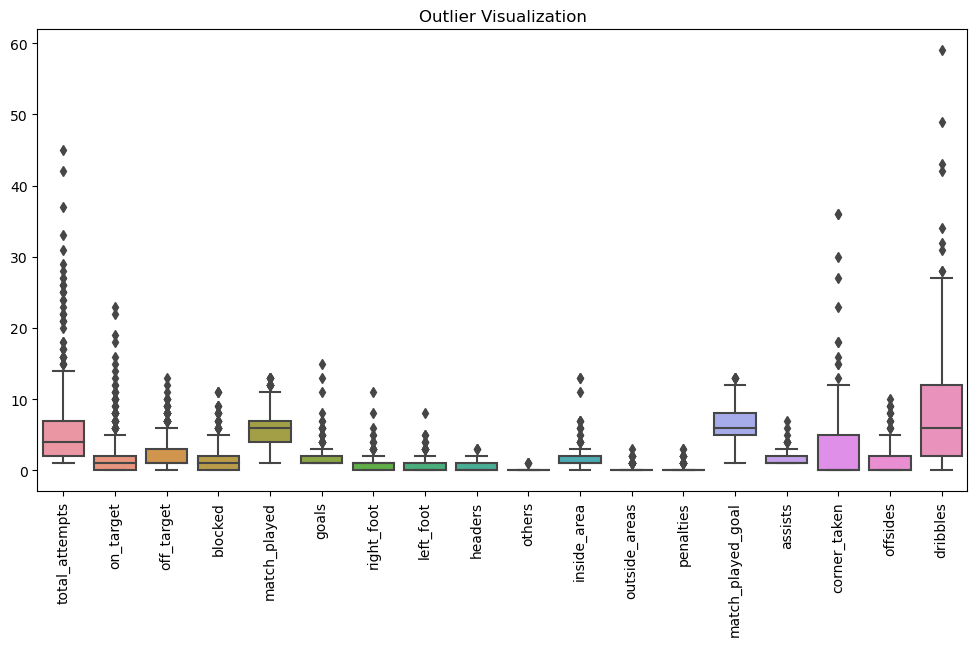

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outlier Visualization")
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['position'], drop_first=True)

print("\n Encoding done")


 Encoding done


In [14]:
df['shot_accuracy'] = df['on_target'] / df['total_attempts'].replace(0, 1)
df['goal_conversion'] = df['goals'] / df['total_attempts'].replace(0, 1)
df['goal_per_match'] = df['goals'] / df['match_played'].replace(0, 1)

print("\n Feature engineering completed")


 Feature engineering completed


In [15]:
df['shot_accuracy'] = df['on_target'] / df['total_attempts'].replace(0,1)

print("\n Feature engineering completed")


 Feature engineering completed


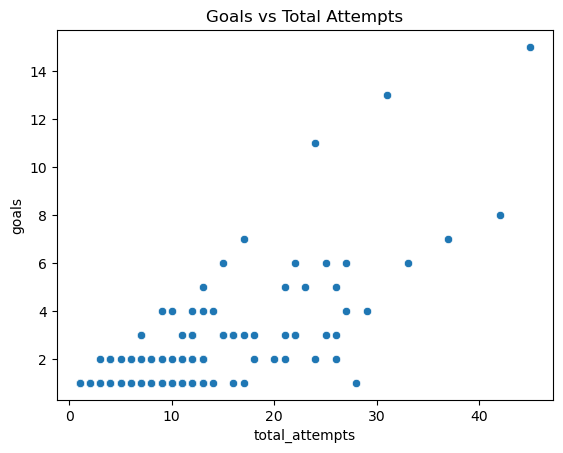

In [13]:
sns.scatterplot(x=df['total_attempts'], y=df['goals'])
plt.title("Goals vs Total Attempts")
plt.show()

In [ ]:
threshold = df['goals'].quantile(0.7)

df['high_scorer'] = (df['goals'] >= threshold).astype(int)

print("\nTarget Distribution:\n", df['high_scorer'].value_counts())


Target Distribution:
 high_scorer
1    432
0    114
Name: count, dtype: int64


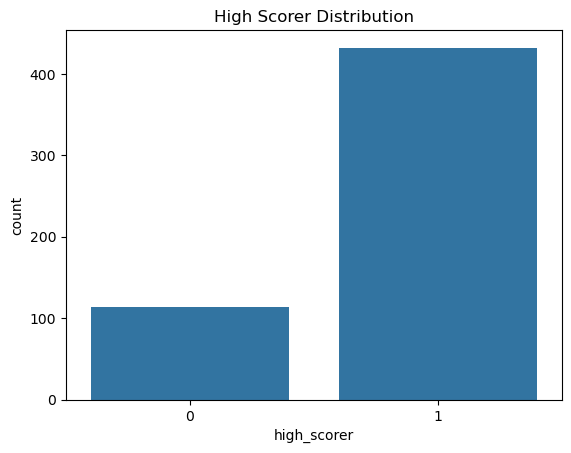

In [ ]:
sns.countplot(x=df['high_scorer'])
plt.title("High Scorer Distribution")
plt.show()

In [ ]:
# List the target variable AND all "leaky" columns that give away the answer
leaky_columns = [
    'high_scorer', 'goals', 'goal_conversion', 'goal_per_match',
    'right_foot', 'left_foot', 'headers', 'others',
    'inside_area', 'outside_areas', 'penalties'
]

# Drop them from the features (and ignore errors if they are already dropped)
features = df.select_dtypes(include=np.number).drop(columns=leaky_columns, errors='ignore')
target = df['high_scorer']

print("\nFair Feature Columns:\n", features.columns)


Fair Feature Columns:
 Index(['total_attempts', 'on_target', 'off_target', 'blocked', 'match_played',
       'match_played_goal', 'assists', 'corner_taken', 'offsides', 'dribbles',
       'shot_accuracy'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (436, 11)
Test Shape: (110, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Scaling completed")


 Scaling completed


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr = LogisticRegression()
rf = RandomForestClassifier(n_estimators=100)
xgb = XGBClassifier(eval_metric='logloss')

lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

print("\n Models trained successfully")


 Models trained successfully


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

print("\nModel Accuracy:")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))


Model Accuracy:
Logistic Regression: 0.7818181818181819
Random Forest: 0.9
XGBoost: 0.9181818181818182


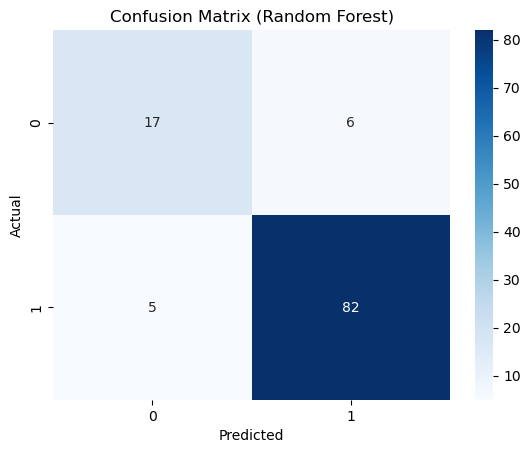

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

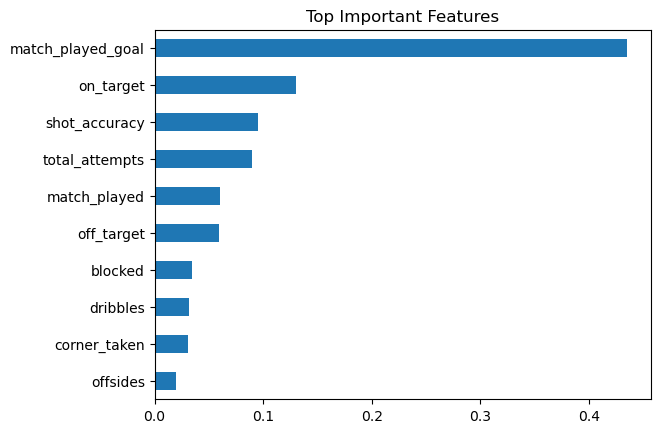

In [ ]:
importance = pd.Series(rf.feature_importances_, index=features.columns)

importance.sort_values().tail(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

In [ ]:
print("\n Pipeline Completed Successfully")
print("Final Dataset Shape:", df.shape)


 Pipeline Completed Successfully
Final Dataset Shape: (546, 25)
